# Block 9 — Handling Outliers: Detecting & Treating Them (SOLUTION)
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing_features.csv` (unchanged since Block 3).

Three parts:
1. **Detect** — run two textbook outlier-detection methods (IQR and Z-score) on `campaign` and `duration`, and see
   where they disagree.
2. **Treat** — try capping (winsorizing) and log-transforming the flagged columns, and measure whether it actually
   changes anything for our model.
3. **The trap** — run the same generic method on `pdays` and watch it break, because `pdays` isn't really a
   continuous measurement — it's 96% one sentinel code.

This block produces one new artifact: `bank_marketing_outliers.csv` — the same 41,188 rows and 50 columns as
`bank_marketing_features.csv`, with four new columns appended (`campaign_capped`, `campaign_log`,
`duration_capped`, `duration_log`). Nothing existing is modified or removed.


## Setup

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 30)

NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"

# Paste the raw GitHub URL for bank_marketing_features.csv below, then remove the leading '#':
# df = pd.read_csv("PASTE_RAW_GITHUB_URL_HERE", sep=";")
print(df.shape)
df[["campaign", "duration", "pdays"]].describe()


## Part 1 — Detecting Outliers: IQR vs. Z-Score

Two standard methods:

- **IQR method:** flag anything outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`
- **Z-score method:** flag anything with `|z| > 3` (more than 3 standard deviations from the mean)

Both are trying to answer the same question — "how far is this point from the bulk of the data?" — but they
measure "far" differently, and that difference matters a lot once a distribution stops looking bell-shaped.


In [2]:
def iqr_bounds(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

results = []
for col in ["campaign", "duration"]:
    s = df[col]
    lower, upper = iqr_bounds(s)
    iqr_mask = (s < lower) | (s > upper)
    z = (s - s.mean()) / s.std()
    z_mask = z.abs() > 3
    results.append({
        "Column": col,
        "Skew": round(s.skew(), 2),
        "IQR bounds": f"[{lower:.1f}, {upper:.1f}]",
        "IQR outliers": f"{iqr_mask.sum()} ({iqr_mask.mean():.2%})",
        "Z-score outliers": f"{z_mask.sum()} ({z_mask.mean():.2%})",
        "Flagged by both": (iqr_mask & z_mask).sum(),
        "IQR-only": (iqr_mask & ~z_mask).sum(),
    })
pd.DataFrame(results)


,Column,Skew,IQR bounds,IQR outliers,Z-score outliers,Flagged by both,IQR-only
0,campaign,4.76,"[-2.0, 6.0]",2406 (5.84%),869 (2.11%),869,1537
1,duration,3.26,"[-223.5, 644.5]",2963 (7.19%),861 (2.09%),861,2102


**IQR flags roughly 3x as many points as Z-score does, on both columns — and everything Z-score catches, IQR also
catches (the "IQR-only" column accounts for the entire gap).** This isn't a coincidence specific to this dataset:
`campaign` and `duration` are both heavily right-skewed (skew 4.8 and 3.3 — a symmetric normal distribution has
skew 0). A large standard deviation, inflated by the same long tail it's supposed to be measuring, makes the
Z-score threshold effectively more permissive. IQR, which only looks at the middle 50% of the data to set its
bounds, doesn't have that problem — but it also doesn't know anything about the shape of the tail beyond "far from
the middle." Neither method is "right"; they encode different assumptions, and skewed data is exactly where the
assumptions start to matter.


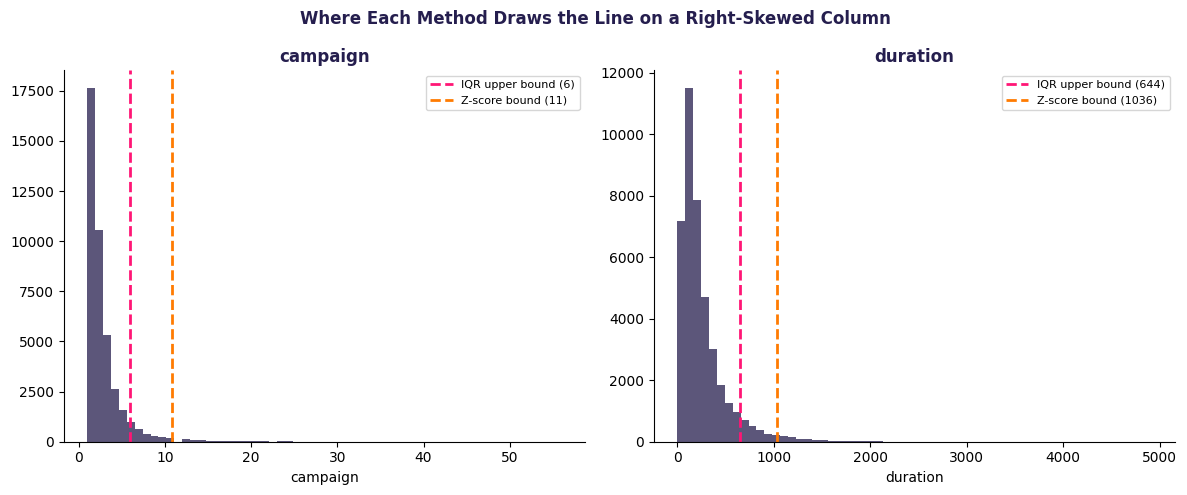

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ["campaign", "duration"]):
    s = df[col]
    lower, upper = iqr_bounds(s)
    ax.hist(s, bins=60, color=NAVY, alpha=0.75)
    ax.axvline(upper, color=PINK, linestyle="--", linewidth=2, label=f"IQR upper bound ({upper:.0f})")
    z_upper = s.mean() + 3 * s.std()
    ax.axvline(z_upper, color=ORANGE, linestyle="--", linewidth=2, label=f"Z-score bound ({z_upper:.0f})")
    ax.set_title(col, color=NAVY, fontweight="bold")
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Where Each Method Draws the Line on a Right-Skewed Column", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()


## Part 2 — Treating Outliers: Capping vs. Log-Transform

Two common ways to reduce the influence of extreme values without deleting rows:

- **Capping (winsorizing):** clip every value to the IQR bounds — extreme values get pulled in to the boundary,
  nothing is removed
- **Log-transform:** `log1p(x)` compresses the scale so that a jump from 1 to 2 calls matters as much,
  proportionally, as a jump from 20 to 40 — long right tails get pulled in without a hard cutoff


In [4]:
Q1, Q3 = df["campaign"].quantile(0.25), df["campaign"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
df["campaign_capped"] = df["campaign"].clip(lower=max(lower, 1), upper=upper)
df["campaign_log"] = np.log1p(df["campaign"])

Qd1, Qd3 = df["duration"].quantile(0.25), df["duration"].quantile(0.75)
IQRd = Qd3 - Qd1
lowerd, upperd = Qd1 - 1.5 * IQRd, Qd3 + 1.5 * IQRd
df["duration_capped"] = df["duration"].clip(lower=max(lowerd, 0), upper=upperd)
df["duration_log"] = np.log1p(df["duration"])

df[["campaign", "campaign_capped", "campaign_log"]].describe()


,campaign,campaign_capped,campaign_log
count,41188.000000,41188.000000,41188.000000
mean,2.567593,2.275274,1.118991
std,2.770014,1.550510,0.491402
min,1.000000,1.000000,0.693147
25%,1.000000,1.000000,0.693147
50%,2.000000,2.000000,1.098612
75%,3.000000,3.000000,1.386294
max,56.000000,6.000000,4.043051


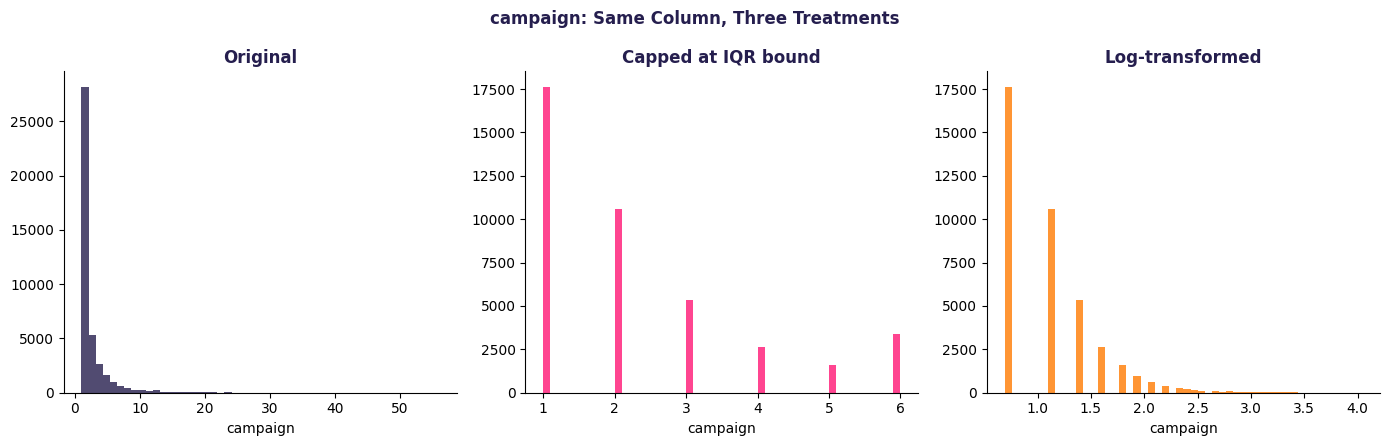

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
axes[0].hist(df["campaign"], bins=50, color=NAVY, alpha=0.8)
axes[0].set_title("Original", color=NAVY, fontweight="bold")
axes[1].hist(df["campaign_capped"], bins=50, color=PINK, alpha=0.8)
axes[1].set_title("Capped at IQR bound", color=NAVY, fontweight="bold")
axes[2].hist(df["campaign_log"], bins=50, color=ORANGE, alpha=0.8)
axes[2].set_title("Log-transformed", color=NAVY, fontweight="bold")
for ax in axes:
    ax.set_xlabel("campaign")
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("campaign: Same Column, Three Treatments", color=NAVY, fontweight="bold")
plt.tight_layout()
plt.show()


**Does any of this change what our model actually learns?** Refit the same `LogisticRegression(C=0.5)` from
Blocks 4-8, swapping only the `campaign` column, and compare test-set ROC-AUC.


In [6]:
feature_cols = [c for c in df.columns if c not in ("education", "y", "duration",
                                                     "campaign_capped", "campaign_log",
                                                     "duration_capped", "duration_log")]
bool_cols = [c for c in df[feature_cols].columns if df[c].dtype == bool]
y = df["y"].values

def fit_and_score(campaign_col):
    Xd = df[feature_cols].copy()
    Xd["campaign"] = df[campaign_col]
    for c in bool_cols:
        Xd[c] = Xd[c].astype(int)
    numeric_to_scale = [
        "age", "campaign", "pdays", "previous",
        "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed",
        "education_rank", "month_sin", "month_cos", "campaign_intensity",
        "emp.var.rate_denoised", "cons.price.idx_denoised", "cons.conf.idx_denoised",
        "euribor3m_denoised", "nr.employed_denoised",
    ]
    Xtr, Xte, ytr, yte = train_test_split(Xd, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    Xtr_s, Xte_s = Xtr.copy(), Xte.copy()
    Xtr_s[numeric_to_scale] = scaler.fit_transform(Xtr[numeric_to_scale])
    Xte_s[numeric_to_scale] = scaler.transform(Xte[numeric_to_scale])
    model = LogisticRegression(max_iter=2000, solver="lbfgs", C=0.5)
    model.fit(Xtr_s, ytr)
    proba = model.predict_proba(Xte_s)[:, 1]
    return roc_auc_score(yte, proba)

auc_raw = fit_and_score("campaign")
auc_capped = fit_and_score("campaign_capped")
auc_log = fit_and_score("campaign_log")

pd.DataFrame({
    "Version": ["Raw campaign", "Capped campaign", "Log campaign"],
    "Test ROC-AUC": [auc_raw, auc_capped, auc_log],
}).round(4)


,Version,Test ROC-AUC
0,Raw campaign,0.7958
1,Capped campaign,0.7960
2,Log campaign,0.7960


**Barely moves — 0.7958 raw vs. 0.7960 for both treated versions.** This is a genuinely useful negative result, not
a wasted exercise: `campaign`'s outliers are rare (5.8% of rows by the more aggressive IQR count) and this is a
*linear* model that already went through `StandardScaler`, which limits how much leverage any single extreme value
gets. Outlier treatment earns its keep on models and metrics that are more sensitive to scale and extreme leverage
points (raw distance-based methods, unregularized linear regression, certain tree splits) — here, it's a legitimate
technique to know and be able to justify skipping, not a checkbox that always changes the outcome.


## Part 3 — The Sentinel-Value Trap: Running the Same Method on `pdays`

`pdays` is "days since the client was last contacted in a previous campaign." Worth checking what generic outlier
detection does to it before trusting either method blindly.


In [7]:
print(f"pdays == 999: {(df['pdays'] == 999).sum()} rows ({(df['pdays'] == 999).mean():.1%})")
df["pdays"].describe()


pdays == 999: 39673 rows (96.3%)


count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

In [8]:
lower, upper = iqr_bounds(df["pdays"])
print(f"IQR bounds on pdays: [{lower}, {upper}]")

z = (df["pdays"] - df["pdays"].mean()) / df["pdays"].std()
iqr_flagged = (df["pdays"] < lower) | (df["pdays"] > upper)
z_flagged = z.abs() > 3
print(f"IQR flags: {iqr_flagged.sum()} ({iqr_flagged.mean():.1%})")
print(f"Z-score flags: {z_flagged.sum()} ({z_flagged.mean():.1%})")
print(f"Same rows flagged by both: {(iqr_flagged == z_flagged).all()}")


IQR bounds on pdays: [999.0, 999.0]
IQR flags: 1515 (3.7%)
Z-score flags: 1515 (3.7%)
Same rows flagged by both: True


**Both methods collapse to the exact same thing: "flag every row that isn't 999."** That's not outlier detection —
it's rediscovering a categorical split by accident. 96.3% of clients were never previously contacted, and `pdays`
uses `999` as a sentinel code for that, not a real day count. Because that one value dominates the distribution,
`Q1 = Q3 = 999`, so `IQR = 0` and *any* deviation from 999 gets flagged — and the Z-score bound degenerates the
same way for the same reason.

The 1,515 rows this "detects" aren't outliers at all — they're clients with a real, small `pdays` value (mean 6
days, max 27), and Block 3 already handled exactly this by engineering `was_contacted_before` as its own boolean
feature. Running IQR or Z-score on a column before checking whether it's secretly a disguised category is how a
sentinel code turns into a fake finding.


## Saving the Output

Append the four treatment columns to the existing 50 and save as a new file — `bank_marketing_features.csv` itself
is untouched, so nothing built in Blocks 4-8 is affected.


In [9]:
out_cols = [c for c in df.columns]  # includes the 4 new columns already added to df above
df.to_csv("bank_marketing_outliers.csv", sep=";", index=False)
print(df.shape)
print("New columns:", [c for c in df.columns if c.endswith("_capped") or c.endswith("_log")])


(41188, 54)
New columns: ['campaign_capped', 'campaign_log', 'duration_capped', 'duration_log']


## Wrap-Up

- IQR and Z-score agree on the extreme cases but disagree by roughly 3x on where the boundary sits, once a column
  is meaningfully skewed — check skew before trusting either method's threshold by default.
- Capping and log-transforming `campaign` barely changed this particular linear model's ROC-AUC (0.7958 → 0.7960) —
  a legitimate result, not a failed experiment. The technique matters more on models and metrics with more leverage
  sensitivity than a regularized, scaled logistic regression.
- Always check whether a numeric column is secretly a disguised category (a sentinel code, a capped meter reading,
  a "999 means N/A" convention) before running generic outlier detection on it — `pdays` is a clean, real example
  of exactly that trap.
